# **8.17. 작사가 인공지능 만들기 [프로젝트]**

<br>

## **17-1. 프로젝트: 멋진 작사가 만들기**

---

#### **Step 0. 환경 세팅**

In [ ]:
# 라이브러리 임포트 및 GPU 체크

In [ ]:
import os, re, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split

print(f"TensorFlow Version: {tf.__version__}")
print("GPU Available: ", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.19.0
GPU Available:  [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


<br>

#### **Step 1. 데이터 다운로드**

(중략)

<br>

#### **Step 2. 데이터 읽어오기**

`glob` 모듈을 사용하면 파일을 읽어오는 작업을 하기가 아주 용이해요. `glob`를 활용하여 모든 txt 파일을 읽어온 후, `raw_corpus` 리스트에 문장 단위로 저장하도록 할게요!

In [ ]:
# 데이터 로드

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import glob #glob 모듈의 glob 함수는 사용자가 제시한 조건에 맞는 파일명을 리스트 형식으로 반환한다
import os

In [ ]:
txt_file_path = '/content/drive/MyDrive/DS_8th/08_딥러닝 알아보기/58일차_3 16(월)/data/lyrics/*' # os.getenv(x)함수는 환경 변수x의 값을 포함하는 문자열 변수를 반환합니다. txt_file_path 에 "/root/aiffel/lyricist/data/lyrics/*" 저장
txt_list = glob.glob(txt_file_path) #txt_file_path 경로에 있는 모든 파일명을 리스트 형식으로 txt_list 에 할당

In [ ]:
raw_corpus = []

# 여러개의 txt 파일을 모두 읽어서 raw_corpus 에 담습니다.
for txt_file in txt_list:
    with open(txt_file, "r") as f:
        raw = f.read().splitlines() #read() : 파일 전체의 내용을 하나의 문자열로 읽어온다. , splitlines()  : 여러라인으로 구분되어 있는 문자열을 한라인씩 분리하여 리스트로 반환
        raw_corpus.extend(raw) # extend() : 리스트함수로 추가적인 내용을 연장 한다.

In [ ]:
print("데이터 크기:", len(raw_corpus))
print("Examples:\n", raw_corpus[:3])

데이터 크기: 187088
Examples:
 ['Looking for some education', 'Made my way into the night', 'All that bullshit conversation']


<br>

In [ ]:
# 데이터 길이 분포 시각화 (EDA)

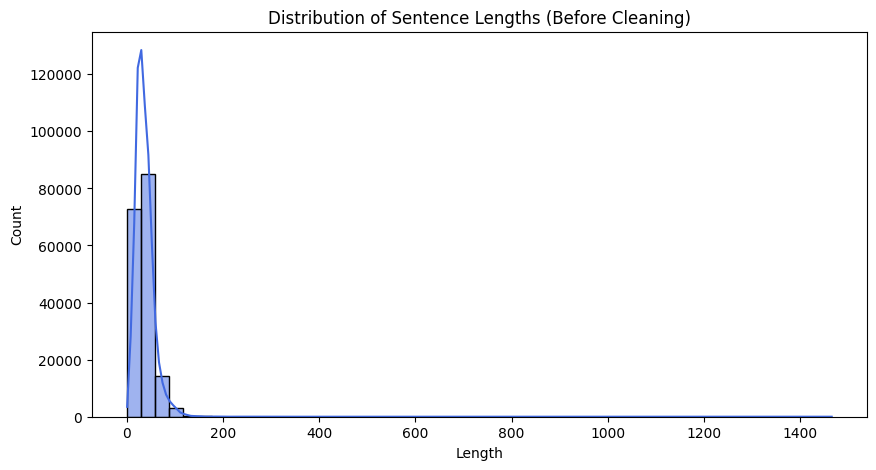

In [ ]:
line_lengths = [len(line) for line in raw_corpus if len(line) > 0]
plt.figure(figsize=(10, 5))
sns.histplot(line_lengths, bins=50, kde=True, color='royalblue')
plt.title("Distribution of Sentence Lengths (Before Cleaning)")
plt.xlabel("Length")
plt.show()

<br>

#### **Step 3. 데이터 정제**

앞서 배운 테크닉들을 활용해 문장 생성에 적합한 모양새로 데이터를 정제하세요!

`preprocess_sentence()` 함수를 만든 것을 기억하시죠? 이를 활용해 데이터를 정제하도록 하겠습니다.

추가로 지나치게 긴 문장은 다른 데이터들이 과도한 Padding을 갖게 하므로 제거합니다. 너무 긴 문장은 노래 가사 작사하기에 어울리지 않을 수도 있겠죠.
그래서 이번에는 문장을 토큰화 했을 때 토큰의 개수가 15개를 넘어가는 문장을 학습 데이터에서 제외하기 를 권합니다.

In [ ]:
# 고도화된 정제 함수

In [ ]:
def preprocess_sentence(sentence):
    sentence = sentence.lower().strip()
    sentence = re.sub(r"([?.!,¿])", r" \1 ", sentence)
    sentence = re.sub(r'[" "]+', " ", sentence)
    sentence = re.sub(r"[^a-zA-Z?.!,¿]+", " ", sentence)
    sentence = sentence.strip()
    sentence = '<start> ' + sentence + ' <end>'
    return sentence

In [ ]:
# 코퍼스 생성 및 필터링 (토큰 수 15개 초과 제거)

In [ ]:
corpus = []
for sentence in raw_corpus:
    if len(sentence) == 0 or sentence[-1] == ":": continue
    preprocessed = preprocess_sentence(sentence)

    # 토큰화 전 공백 기준으로 대략적 필터링 가능
    if len(preprocessed.split()) > 15: continue
    corpus.append(preprocessed)

print(f"Filtered Corpus Size: {len(corpus):,}")

Filtered Corpus Size: 156,013


In [ ]:
# Vectorization (Tokenizing & Padding)

In [ ]:
def tokenize(corpus):
    tokenizer = tf.keras.preprocessing.text.Tokenizer(
        num_words=15000,
        filters=' ',
        oov_token="<unk>"
    )
    tokenizer.fit_on_texts(corpus)
    tensor = tokenizer.texts_to_sequences(corpus)
    # Post-padding은 RNN 계열에서 정보 손실을 방지하기 위해 선택 (maxlen=15)
    tensor = tf.keras.preprocessing.sequence.pad_sequences(tensor, padding='post', maxlen=15)

    return tensor, tokenizer

In [ ]:
tensor, tokenizer = tokenize(corpus)

In [ ]:
# 데이터 형태 최종 확인

In [ ]:
print(f"Tensor Shape: {tensor.shape}")
print(f"Vocabulary Size: {tokenizer.num_words}")

Tensor Shape: (156013, 15)
Vocabulary Size: 15000


<br>

#### **Step 4. 평가 데이터셋 분리 (& tf.data Pipeline)**

훈련 데이터와 평가 데이터를 분리하세요!

`tokenize()` 함수로 데이터를 Tensor로 변환한 후, sklearn 모듈의 `train_test_split()` 함수를 사용해 훈련 데이터와 평가 데이터를 분리하도록 하겠습니다. 단어장의 크기는 12,000 이상 으로 설정하세요! 총 데이터의 20% 를 평가 데이터셋으로 사용해 주세요!

In [ ]:
# Source/Target 분리
# [:, :-1] : <end> 제거, [:, 1:] : <start> 제거

In [ ]:
src_input = tensor[:, :-1]
tgt_input = tensor[:, 1:]

In [ ]:
# Train/Val Split (80:20)

In [ ]:
enc_train, enc_val, dec_train, dec_val = train_test_split(
    src_input, tgt_input, test_size=0.2, random_state=42
)

In [ ]:
# tf.data 파이프라인 구축 (Prefetch & Autotune)

In [ ]:
BUFFER_SIZE = 10000
BATCH_SIZE = 128

In [ ]:
def create_dataset(x, y):
    ds = tf.data.Dataset.from_tensor_slices((x, y))
    ds = ds.shuffle(BUFFER_SIZE)
    ds = ds.batch(BATCH_SIZE, drop_remainder=True)
    ds = ds.prefetch(tf.data.experimental.AUTOTUNE)
    return ds

In [ ]:
train_dataset = create_dataset(enc_train, dec_train)
val_dataset = create_dataset(enc_val, dec_val)

In [ ]:
print(f"Train Batches: {len(train_dataset)}")
print(f"Validation Batches: {len(val_dataset)}")

Train Batches: 975
Validation Batches: 243


<br>

#### **Step 5. 인공지능 만들기**

모델의 Embedding Size와 Hidden Size를 조절하며 10 Epoch 안에 val_loss 값을 2.2 수준으로 줄일 수 있는 모델을 설계하세요!

<br>

##### **1) 모델 디자인**

LSTM 레이어의 드롭아웃을 적용하여 과적합을 방지하고 구조를 명확히 함.

In [ ]:
# Subclassing

In [ ]:
class LyricsGenerator(tf.keras.Model):
    def __init__(self, vocab_size, embedding_size, hidden_size):
        super(LyricsGenerator, self).__init__()
        self.embedding = tf.keras.layers.Embedding(vocab_size, embedding_size)
        # Recurrent Dropout은 실전에서 성능 향상에 큰 도움을 줌
        self.lstm_1 = tf.keras.layers.LSTM(hidden_size, return_sequences=True, dropout=0.3)
        self.lstm_2 = tf.keras.layers.LSTM(hidden_size, return_sequences=True, dropout=0.3)
        self.linear = tf.keras.layers.Dense(vocab_size)

    def call(self, x):
        out = self.embedding(x)
        out = self.lstm_1(out)
        out = self.lstm_2(out)
        out = self.linear(out)
        return out

In [ ]:
# Hyperparameters

In [ ]:
EMBEDDING_SIZE = 512
HIDDEN_SIZE = 1024
VOCAB_SIZE = tokenizer.num_words + 1

In [ ]:
model = LyricsGenerator(VOCAB_SIZE, EMBEDDING_SIZE, HIDDEN_SIZE)

In [ ]:
# 더미 데이터로 모델 빌드 및 Summary 확인

In [ ]:
for src_sample, tgt_sample in train_dataset.take(1): break
model(src_sample)

<tf.Tensor: shape=(128, 14, 15001), dtype=float32, numpy=
array([[[ 5.9126094e-05,  2.9106025e-04,  7.4632289e-06, ...,
          2.4313692e-04, -5.3301388e-05,  9.3929346e-05],
        [ 1.3922165e-04,  4.4939970e-04,  1.2382037e-05, ...,
          4.5470611e-04, -2.4858562e-05, -8.4280538e-05],
        [ 8.4587111e-05,  5.3091830e-04, -6.5182183e-05, ...,
          4.6163463e-04,  1.7606461e-04, -4.2586224e-04],
        ...,
        [-1.2330414e-03,  1.5787797e-03,  5.4249133e-04, ...,
          8.6150883e-04, -1.0330877e-03,  1.5337642e-03],
        [-1.3817478e-03,  1.8444982e-03,  4.4953136e-04, ...,
          4.8228822e-04, -1.4514689e-03,  1.9476876e-03],
        [-1.4799597e-03,  2.1025923e-03,  3.6924821e-04, ...,
          9.8227785e-05, -1.8388710e-03,  2.3331561e-03]],

       [[ 5.9126094e-05,  2.9106025e-04,  7.4632289e-06, ...,
          2.4313692e-04, -5.3301388e-05,  9.3929346e-05],
        [ 3.2211683e-04,  5.0551683e-04,  4.5077588e-05, ...,
          1.6839553e-04, 

In [ ]:
model.summary()

Model: "lyrics_generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (128, 14, 512)         │     7,680,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (128, 14, 1024)        │     6,295,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (128, 14, 1024)        │     8,392,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (128, 14, 15001)       │    15,376,025 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,744,793 (143.98 MB)

 Trainable params: 37,744,793 (143.98 MB)

 Non-trainable params: 0 (0.00 B)

<br>

##### **2) 모델 학습 (Callbacks & Monitoring)**

In [ ]:
# Optimizer & Loss

In [ ]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True, reduction='none')

In [ ]:
# 모델 컴파일

In [ ]:
model.compile(loss=loss, optimizer=optimizer)

In [ ]:
# Callbacks

In [ ]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=3, monitor='val_loss'),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=5),
    tf.keras.callbacks.ModelCheckpoint(
        'best_lyricist_model.weights.h5',
        save_best_only=True,
        save_weights_only=True
    )
]

In [ ]:
# 모델 학습

In [ ]:
history = model.fit(
    train_dataset,
    epochs=30,
    validation_data=val_dataset,
    callbacks=callbacks
)

Epoch 1/30
975/975 ━━━━━━━━━━━━━━━━━━━━ 23s 22ms/step - loss: 3.2520 - val_loss: 3.0024 - learning_rate: 0.0010
Epoch 2/30
975/975 ━━━━━━━━━━━━━━━━━━━━ 21s 22ms/step - loss: 2.8569 - val_loss: 2.8356 - learning_rate: 0.0010
Epoch 3/30
975/975 ━━━━━━━━━━━━━━━━━━━━ 21s 22ms/step - loss: 2.6708 - val_loss: 2.7322 - learning_rate: 0.0010
Epoch 4/30
975/975 ━━━━━━━━━━━━━━━━━━━━ 21s 22ms/step - loss: 2.5142 - val_loss: 2.6559 - learning_rate: 0.0010
Epoch 5/30
975/975 ━━━━━━━━━━━━━━━━━━━━ 21s 22ms/step - loss: 2.3707 - val_loss: 2.5957 - learning_rate: 0.0010
Epoch 6/30
975/975 ━━━━━━━━━━━━━━━━━━━━ 21s 22ms/step - loss: 2.2372 - val_loss: 2.5541 - learning_rate: 0.0010
Epoch 7/30
975/975 ━━━━━━━━━━━━━━━━━━━━ 21s 22ms/step - loss: 2.1141 - val_loss: 2.5254 - learning_rate: 0.0010
Epoch 8/30
975/975 ━━━━━━━━━━━━━━━━━━━━ 21s 22ms/step - loss: 2.0024 - val_loss: 2.5028 - learning_rate: 0.0010
Epoch 9/30
975/975 ━━━━━━━━━━━━━━━━━━━━ 21s 22ms/step - loss: 1.9007 - val_loss: 2.4894 - learning_rate:

In [ ]:
# 학습 결과 시각화

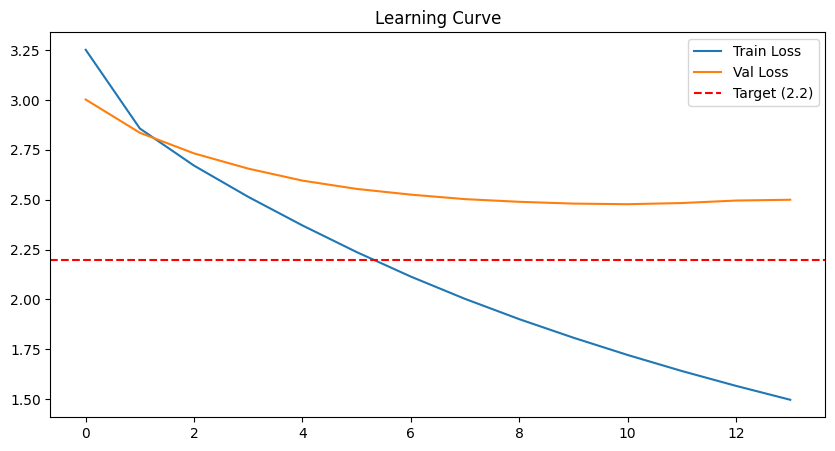

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.axhline(y=2.2, color='r', linestyle='--', label='Target (2.2)')
plt.title("Learning Curve")
plt.legend()
plt.show()

<br>

##### **3) Inference (Text Generation)**

In [ ]:
# 결과 확인

In [ ]:
def generate_lyrics(model, tokenizer, init_sentence="<start> i love", max_len=20):
    test_input = tokenizer.texts_to_sequences([init_sentence])
    test_tensor = tf.convert_to_tensor(test_input, dtype=tf.int64)
    end_token = tokenizer.word_index["<end>"]

    while True:
        predict = model(test_tensor)
        # 마지막 타임스텝의 예측값 중 가장 높은 인덱스 추출
        predict_word = tf.argmax(tf.nn.softmax(predict, axis=-1), axis=-1)[:, -1]

        # 예측된 단어를 시퀀스에 결합
        test_tensor = tf.concat([test_tensor, tf.expand_dims(predict_word, axis=0)], axis=-1)

        if predict_word.numpy()[0] == end_token or test_tensor.shape[1] >= max_len:
            break

    generated = ""
    for word_index in test_tensor[0].numpy():
        generated += tokenizer.index_word[word_index] + " "

    return generated

In [ ]:
print("🎤 Generated Lyrics:")
print(generate_lyrics(model, tokenizer, init_sentence="<start> i love"))

🎤 Generated Lyrics:
<start> i love you , i love you <end> 


<br>

##### **4) 모델 평가**

In [ ]:
# Perplexity 계산

In [ ]:
history_dict = history.history
train_ppl = np.exp(history_dict['loss'])
val_ppl = np.exp(history_dict['val_loss'])

In [ ]:
print(f"Final Validation PPL: {val_ppl[-1]:.2f}")

Final Validation PPL: 12.18


In [ ]:
# 시각화

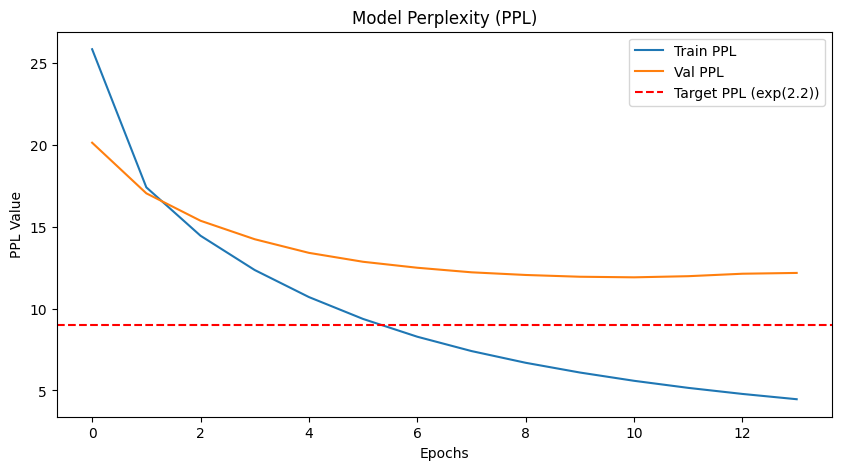

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(train_ppl, label='Train PPL')
plt.plot(val_ppl, label='Val PPL')
plt.axhline(y=np.exp(2.2), color='r', linestyle='--', label='Target PPL (exp(2.2))')
plt.title("Model Perplexity (PPL)")
plt.xlabel("Epochs")
plt.ylabel("PPL Value")
plt.legend()
plt.show()

<br><br>

## **17-2. 프로젝트 제출**

---

#### **루브릭**

| 평가문항 | 상세기준 | 수행여부 |
| :--- | :--- | :---: |
| 1. 데이터의 전처리 및 구성과정이 체계적으로 진행되었는가? | 특수문자 제거, 토크나이저 생성, 패딩 처리의 작업들이 빠짐없이 진행되었는가? | O |
| 2. 가사 텍스트 생성 모델이 정상적으로 동작하는가? | 텍스트 제너레이션 결과로 생성된 문장이 해석 가능한 문장인가? | O |
| 3. 텍스트 생성모델이 안정적으로 학습되었는가? | 텍스트 생성모델의 validation loss가 2.2 이하로 낮아졌는가? | 2.47 |